In [2]:
'''# Create the directory structure
!mkdir -p ./data/sets/nuscenes
# Download the mini dataset directly using wget
!wget https://www.nuscenes.org/data/v1.0-mini.tgz -O ./data/sets/nuscenes/v1.0-mini.tgz'''

--2026-02-22 03:57:07--  https://www.nuscenes.org/data/v1.0-mini.tgz
Resolving www.nuscenes.org (www.nuscenes.org)... 52.84.205.120, 52.84.205.51, 52.84.205.41, ...
Connecting to www.nuscenes.org (www.nuscenes.org)|52.84.205.120|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4167696325 (3.9G) [application/x-tar]
Saving to: ‘./data/sets/nuscenes/v1.0-mini.tgz’

./data/sets/nuscene 100%[===================>]   3.88G   981KB/s    in 67m 18s 

2026-02-22 05:04:27 (1008 KB/s) - ‘./data/sets/nuscenes/v1.0-mini.tgz’ saved [4167696325/4167696325]



In [ ]:
#%pip install nuscenes-devkit

In [3]:
'''# Extract the archive into the same directory
!tar -xf ./data/sets/nuscenes/v1.0-mini.tgz -C ./data/sets/nuscenes/

# Optional: Delete the archive to free up storage space
!rm ./data/sets/nuscenes/v1.0-mini.tgz'''

In [9]:
from nuscenes.utils.data_classes import RadarPointCloud

In [1]:
from nuscenes.nuscenes import NuScenes

# Initialize the dataset using the relative path you just created
nusc = NuScenes(version='v1.0-mini', dataroot='./data/sets/nuscenes', verbose=True)

# Print out the available scenes to confirm success
nusc.list_scenes()

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.381 seconds.
Reverse indexing ...
Done reverse indexing in 0.0 seconds.
scene-0061, Parked truck, construction, intersectio... [18-07-24 03:28:47]   19s, singapore-onenorth, #anns:4622
scene-0103, Many peds right, wait for turning car, ... [18-08-01 19:26:43]   19s, boston-seaport, #anns:2046
scene-0655, Parking lot, parked cars, jaywalker, be... [18-08-27 15:51:32]   20s, boston-seaport, #anns:2332
scene-0553, Wait at intersection, bicycle, large tr... [18-08-28 20:48:16]   20s, boston-seaport, #anns:1950
scene-0757, Arrive at busy intersection, bus, wait ... [18-08-30 19:25:08]   20s, boston-seaport, #anns:592
scene-0796, Scooter, peds on sidewalk, bus, cars, t... [18-10-02 02:52:24]   20s, singapore-queensto, #anns:708
scene-0916, Parki

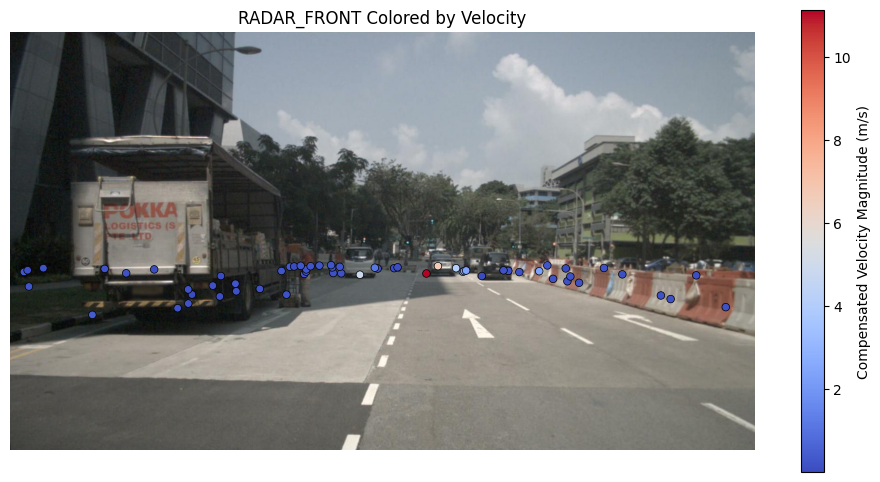

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pyquaternion import Quaternion
from nuscenes.utils.data_classes import RadarPointCloud
from nuscenes.utils.geometry_utils import view_points

# 1. Get the tokens for the specific sample and sensors
my_sample = nusc.scene[0]
first_sample_token = my_sample['first_sample_token']
sample = nusc.get('sample', first_sample_token)

cam_token = sample['data']['CAM_FRONT']
radar_token = sample['data']['RADAR_FRONT']

cam_data = nusc.get('sample_data', cam_token)
radar_data = nusc.get('sample_data', radar_token)

# 2. Load the raw Image and Radar Point Cloud data
cam_path = nusc.get_sample_data_path(cam_token)
radar_path = nusc.get_sample_data_path(radar_token)

im = Image.open(cam_path)
pc = RadarPointCloud.from_file(radar_path)

# 3. Fetch calibration and ego pose records
cs_radar = nusc.get('calibrated_sensor', radar_data['calibrated_sensor_token'])
ep_radar = nusc.get('ego_pose', radar_data['ego_pose_token'])
cs_cam = nusc.get('calibrated_sensor', cam_data['calibrated_sensor_token'])
ep_cam = nusc.get('ego_pose', cam_data['ego_pose_token'])

# 4. Transform points: RADAR -> Ego -> Global -> Ego -> CAMERA
# Step A: Radar frame to Ego frame
pc.rotate(Quaternion(cs_radar['rotation']).rotation_matrix)
pc.translate(np.array(cs_radar['translation']))

# Step B: Ego frame to Global frame
pc.rotate(Quaternion(ep_radar['rotation']).rotation_matrix)
pc.translate(np.array(ep_radar['translation']))

# Step C: Global frame to Ego frame (at the time of the camera image)
pc.translate(-np.array(ep_cam['translation']))
pc.rotate(Quaternion(ep_cam['rotation']).rotation_matrix.T)

# Step D: Ego frame to Camera frame
pc.translate(-np.array(cs_cam['translation']))
pc.rotate(Quaternion(cs_cam['rotation']).rotation_matrix.T)

# 5. Extract Compensated Velocity (Indices 8 and 9 in nuScenes RadarPointCloud)
vx_comp = pc.points[8, :]
vy_comp = pc.points[9, :]
# Calculate velocity magnitude (m/s)
velocities = np.sqrt(vx_comp**2 + vy_comp**2)

# 6. Project 3D Camera coordinates to 2D Image pixels using the camera intrinsic matrix
depths = pc.points[2, :]
points = view_points(pc.points[:3, :], np.array(cs_cam['camera_intrinsic']), normalize=True)

# 7. Create a mask to filter out points behind the camera or outside the image bounds
mask = np.ones(depths.shape[0], dtype=bool)
mask = np.logical_and(mask, depths > 0)
mask = np.logical_and(mask, points[0, :] > 0)
mask = np.logical_and(mask, points[0, :] < im.size[0])
mask = np.logical_and(mask, points[1, :] > 0)
mask = np.logical_and(mask, points[1, :] < im.size[1])

points = points[:, mask]
velocities = velocities[mask]

# 8. Plot the result
plt.figure(figsize=(12, 6))
plt.imshow(im)
# Color the scatter plot using the 'coolwarm' colormap based on velocity
scatter = plt.scatter(points[0, :], points[1, :], c=velocities, cmap='coolwarm', s=30, edgecolors='black', linewidth=0.5)
plt.colorbar(scatter, label='Compensated Velocity Magnitude (m/s)')
plt.title('RADAR_FRONT Colored by Velocity')
plt.axis('off')
plt.show()

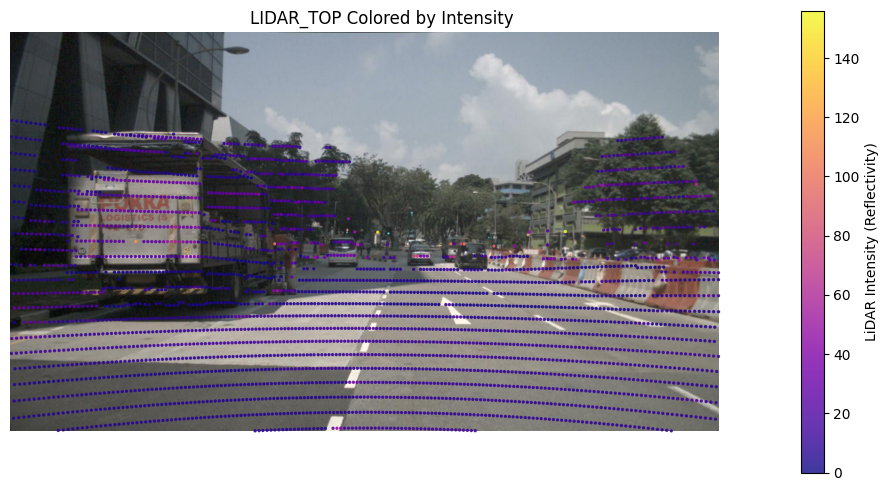

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pyquaternion import Quaternion
from nuscenes.utils.data_classes import LidarPointCloud
from nuscenes.utils.geometry_utils import view_points

# 1. Get the tokens for the specific sample
my_sample = nusc.scene[0]
first_sample_token = my_sample['first_sample_token']
sample = nusc.get('sample', first_sample_token)

cam_token = sample['data']['CAM_FRONT']
lidar_token = sample['data']['LIDAR_TOP'] # Switched to LiDAR

cam_data = nusc.get('sample_data', cam_token)
lidar_data = nusc.get('sample_data', lidar_token)

# 2. Load the raw Image and Lidar Point Cloud data
cam_path = nusc.get_sample_data_path(cam_token)
lidar_path = nusc.get_sample_data_path(lidar_token)

im = Image.open(cam_path)
pc = LidarPointCloud.from_file(lidar_path) # Switched to LidarPointCloud

# 3. Fetch calibration and ego pose records
cs_lidar = nusc.get('calibrated_sensor', lidar_data['calibrated_sensor_token'])
ep_lidar = nusc.get('ego_pose', lidar_data['ego_pose_token'])
cs_cam = nusc.get('calibrated_sensor', cam_data['calibrated_sensor_token'])
ep_cam = nusc.get('ego_pose', cam_data['ego_pose_token'])

# 4. Transform points: LIDAR -> Ego -> Global -> Ego -> CAMERA
pc.rotate(Quaternion(cs_lidar['rotation']).rotation_matrix)
pc.translate(np.array(cs_lidar['translation']))

pc.rotate(Quaternion(ep_lidar['rotation']).rotation_matrix)
pc.translate(np.array(ep_lidar['translation']))

pc.translate(-np.array(ep_cam['translation']))
pc.rotate(Quaternion(ep_cam['rotation']).rotation_matrix.T)

pc.translate(-np.array(cs_cam['translation']))
pc.rotate(Quaternion(cs_cam['rotation']).rotation_matrix.T)

# 5. Extract Intensity (Index 3 in nuScenes LidarPointCloud)
depths = pc.points[2, :]
intensities = pc.points[3, :] 

# 6. Project 3D Camera coordinates to 2D Image pixels
points = view_points(pc.points[:3, :], np.array(cs_cam['camera_intrinsic']), normalize=True)

# 7. Mask out points behind the camera or outside the image bounds
mask = np.ones(depths.shape[0], dtype=bool)
mask = np.logical_and(mask, depths > 0)
mask = np.logical_and(mask, points[0, :] > 0)
mask = np.logical_and(mask, points[0, :] < im.size[0])
mask = np.logical_and(mask, points[1, :] > 0)
mask = np.logical_and(mask, points[1, :] < im.size[1])

points = points[:, mask]
intensities = intensities[mask]

# 8. Plot the result
plt.figure(figsize=(12, 6))
plt.imshow(im)
# Notice the smaller marker size (s=2) because LiDAR is vastly more dense than RADAR
scatter = plt.scatter(points[0, :], points[1, :], c=intensities, cmap='plasma', s=2, alpha=0.8)
plt.colorbar(scatter, label='LiDAR Intensity (Reflectivity)')
plt.title('LIDAR_TOP Colored by Intensity')
plt.axis('off')
plt.show()

In [8]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np

class NuScenesFusionDataset(Dataset):
    def __init__(self, nusc_env, scene_list):
        self.nusc = nusc_env
        self.samples = []
        
        # Flatten all samples from the provided scenes into a single indexable list
        for scene in scene_list:
            current_token = scene['first_sample_token']
            while current_token != '':
                sample = self.nusc.get('sample', current_token)
                self.samples.append(sample)
                current_token = sample['next']
                
        # Define image transforms: Aggressive downsampling is mandatory for 4GB VRAM
        self.img_transform = transforms.Compose([
            transforms.Resize((224, 400)), # Shrinking the native 1600x900 resolution
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        
        # --- 1. Load and Transform Camera Image ---
        cam_token = sample['data']['CAM_FRONT']
        cam_path = self.nusc.get_sample_data_path(cam_token)
        image = Image.open(cam_path).convert('RGB')
        img_tensor = self.img_transform(image)
        
        # --- 2. Load RADAR Data ---
        radar_token = sample['data']['RADAR_FRONT']
        radar_path = self.nusc.get_sample_data_path(radar_token)
        
        # FIX: Use the official class to parse the .pcd file safely
        radar_pc = RadarPointCloud.from_file(radar_path)
        
        # pc.points is stored as shape (18, N). 
        # Extract x, y, z, and compensated velocities (indices 0, 1, 2, 8, 9)
        radar_features = radar_pc.points[[0, 1, 2, 8, 9], :]
        
        # Transpose to shape (N, 5) so each row represents one point
        radar_features = radar_features.T
        
        # Convert to PyTorch tensor
        radar_tensor = torch.tensor(radar_features, dtype=torch.float32)
        
        # Return a packaged dictionary for the DataLoader
        return {
            'image': img_tensor,
            'radar': radar_tensor,
            'sample_token': sample['token']
        }

In [5]:
'''# Installing PyTorch, TorchVision, and TorchAudio with CUDA 11.8 support 
# (Highly stable for WSL2 and RTX 3000 series)
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118'''

Looking in indexes: https://download.pytorch.org/whl/cu118
Note: you may need to restart the kernel to use updated packages.


In [10]:
fusion_dataset = NuScenesFusionDataset(nusc, nusc.scene[:2])
train_loader = DataLoader(fusion_dataset, batch_size=1, shuffle=True, num_workers=0)

for batch in train_loader:
    print("✅ Successfully loaded a batch!")
    print("-" * 30)
    print(f"Image Tensor Shape: {batch['image'].shape}")
    print(f"RADAR Tensor Shape: {batch['radar'].shape}")
    break

✅ Successfully loaded a batch!
------------------------------
Image Tensor Shape: torch.Size([1, 3, 224, 400])
RADAR Tensor Shape: torch.Size([1, 63, 5])
